<div class="usecase-title">School Enrolment Trends Data Visualisation Analysis Project</div>

<div class="usecase-authors"><b>Authored by: </b> Arvind Sharma</div>

<div class="usecase-duration"><b>Duration:</b> 60 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, Data analysis, Data visualisation, Statistical analysis</div>
</div>

<div class="usecase-section-header">Scenario</div>

The problem I am trying to solve is how to identify which areas across Victoria are experiencing growing or declining student enrolments so education planners can make better decisions about where schools, facilities, and resources will be needed in the future.

<div class="usecase-section-header">What this use case will teach you</div>

At the completion of my work on this use case, I will improve my skills in Python, statistical analysis, and technical documentation by working with real enrolment and location datasets to support education planning decisions.

<div class="usecase-section-header">Using Enrolment Data for Education Planning</div>

Victorian school enrolment data is collected each February and published as administrative census data. While a single year provides a snapshot of student numbers, education planning requires trend analysis over time to identify which areas are growing or declining and where future school demand may increase.

Enrolment data was initially only available for 2024. Additional February census files for 2022, 2023, and 2025 were sourced online so trends could be compared across four years. These datasets were combined with official school location records from the Victorian Government open data portal, DataVic.

The analysis examines enrolment trends across Victoria, Local Government Areas (LGAs), and selected high-growth regions to support evidence-based education planning and infrastructure development.

## Chronological summary of the analysis

### Data collection: (Step 1 to Step 3) 
Enrolment was initially only available for 2024. Additional February census files for 2022, 2023, and 2025 were sourced online so trends could be compared across four years. School locations came from the Victorian open-data API. Together, that provided enrolment plus geography such as LGA, administrative region, and coordinates.

### Cleaning and column alignment (Step 4 and Step 5)
The yearly enrolment files did not match perfectly. Column names were cleaned and standardised, and `School_No` was kept as text for consistent keys. Only columns that appeared in all four years were kept when stacking the files, so comparisons across years used the same fields and avoided silent gaps.

### Duplicate school numbers and unique IDs (Step 6 to Step 9)
The same `School_No` could appear more than once in a year because of different `Entity_Type` values. A `Unique_School_ID` was built by combining entity type with school number, using the same rule for enrolment and for locations. Later school-level calculations pivoted on this ID, not on school name, because names can differ by year and would wrongly split one school across two rows.

### Analytical cohort - open schools, four years (Step 10 to Step 13) 
The enrolment table was limited to schools marked open and present in every year from 2022 to 2025. That produced a balanced panel: the same schools each year, which is fair for trend comparisons. It does not include schools that opened after 2022, closed before 2025, changed status, or missed a year, so conclusions should describe this cohort rather than the whole state system.

### Merge with locations (Step 14 and Step 15)
The cleaned enrolment panel was merged to the location table on `Unique_School_ID` using an inner join, keeping only schools found in both. The result pairs yearly enrolment with LGA and mapping fields for geographic analysis.

### LGA coverage (Step 16 and Step 17)
Analysis then used only LGAs that appeared in the merged dataset (80 in your run). For each LGA, the count of distinct schools in the cohort was checked so large changes could be read against how many schools sit in that area.

### System-wide totals and primary versus secondary (Step 18 and Step 19)
Total enrolment by year was summed for the cohort. Totals rose across the four years, while the year-on-year growth rate eased toward 2025. Enrolment was also split into primary and secondary: secondary grew steadily through the period, while primary softened by the last year, so the latest picture was not “everything growing the same way.”

### Prep and Year 7 - simple entry signals (Step 20)
Prep totals fell year on year in the cohort, while Year 7 totals rose (with a stronger rise into 2025). That was used as a lightweight read on typical entry points, alongside the overall totals, not as a full population forecast.

### LGA change from 2022 to 2025 (Step 21 and Step 22)
For each LGA, enrolment was summed in 2022 and 2025. LGAs were ranked mainly by absolute change, with percentage change shown beside it for context. This highlighted fast-growing areas (including Casey, Melton, Greater Dandenong, Wyndham, Greater Geelong, and Hume among others) and a separate list highlighted the largest absolute declines. Declines in metro LGAs were often small in percentage terms on many schools; some smaller LGAs showed larger percentage drops on smaller student totals.

### School counts per LGA (Step 23 and Step 24)
The growth and decline tables were joined with counts of schools per LGA so reviewers could see whether a large student-number change was spread across many sites or concentrated in fewer schools.

### Primary versus secondary within the biggest movers (Step 25 and Step 26)
For the five LGAs with the largest total growth and the five with the largest total decline, primary and secondary were compared separately between 2022 and 2025. Some growth corridors were secondary-led; some were more balanced. Some declining LGAs showed primary falling while secondary still rose, which complicates a single “declining area” label.

### School-level concentration - case studies (Step 27 to Step 31)
For several high-growth LGAs, change was computed school by school. Pivoting only on `Unique_School_ID` was important so school totals matched the LGA totals. The pattern was that net LGA growth often sits in a handful of campuses. Greater Dandenong was the strongest example of one very large school accounting for most of the LGA net increase. Melton, Wyndham, Casey, and Greater Geelong showed strong concentration to different degrees, often mixing growth-area government schools (including many P–9 and primary campuses) with large non-government growth, while other schools in the same LGA declined, consistent with catchment churn in outer growth areas.

### Closing synthesis - Conclusion
The five LGAs were summarised together: all showed large net growth in this cohort, but differed in how concentrated that growth was and whether one campus or a small group dominated the LGA total. The main methodological point for readers is that LGA headlines and school-level detail answer different questions, and sector mix matters if the focus is public-sector infrastructure rather than enrolment in all sectors combined.

### Data collection:

**Step 1**  
The required Python libraries are imported first so the notebook can load data, clean tables, analyse enrolment trends.

In [10]:
import pandas as pd
import requests
from io import StringIO

**Step 2**  
Download school location records from the Victorian open-data service and turn them into a single table of schools with addresses and map coordinates.

*School location records are needed to add geographic information such as LGAs, regions, and map coordinates. This allows enrolment trends to be analysed spatially rather than only as statewide totals.*

In [12]:
# Import the school locations data set using API
base_url = "https://discover.data.vic.gov.au/api/3/action/datastore_search"

resource_id = "a70cb615-ed28-48b6-bebe-2d0d346f7927"

url = f"{base_url}?resource_id={resource_id}&limit=5000"

response = requests.get(url)

if response.status_code == 200:

    data = response.json()

    school_locations_df = pd.DataFrame(data["result"]["records"])

    print(school_locations_df.head())

else:

    print(f"Request failed with status code {response.status_code}")

   _id Education_Sector Entity_Type School_No                    School_Name  \
0    1         Catholic           2        20                 Parade College   
1    2         Catholic           2        25       Simonds Catholic College   
2    3         Catholic           2        26    St Mary’s College Melbourne   
3    4         Catholic           2        28  St Patrick's College Ballarat   
4    5         Catholic           2        29            St Patrick's School   

  School_Type             Address_Line_1 Address_Line_2    Address_Town  \
0   Secondary           1436 Plenty Road           None        BUNDOORA   
1   Secondary        273 Victoria Street           None  WEST MELBOURNE   
2   Secondary         11 Westbury Street           None   ST KILDA EAST   
3   Secondary          1431 Sturt Street           None        BALLARAT   
4     Primary  119 Drummond Street South           None        BALLARAT   

  Address_State  ...     Postal_Town Postal_State Postal_Postcode  \

**Step 3**  
Load the four yearly enrolment spreadsheets from the GitHub, tidy the column names, standardise the school number as text, tag each row with its year, and stack everything into one combined enrolment table.

*The yearly enrolment files are combined into one table so trends can be compared across multiple years instead of analysing each file separately. Standardising column names and school numbers ensures the files can be merged consistently.*

In [14]:
# load the enrolment data for 2022 to 2025 from the GitHub repo)
files = {
    "dv335-allschoolsFTEenrolmentsFeb2022.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv335-allschoolsFTEenrolmentsFeb2022.csv",
    "dv355-VIC All Schools Enrolments 2023.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv355-VIC%20All%20Schools%20Enrolments%202023.csv",
    "dv377_DataVic-AllSchoolsEnrolments-2024.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv377_DataVic-AllSchoolsEnrolments-2024.csv",
    "dv403-AllSchoolsEnrolments-2025.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv403-AllSchoolsEnrolments-2025.csv",
}

dfs = []
for fname, url in files.items():
    df = pd.read_csv(url, encoding="latin1")
    df.columns = (
        df.columns
        .str.strip()
        .str.replace('"', '', regex=False)
        .str.replace(' ', '_')
    )
    df["School_No"] = df["School_No"].astype(str).str.strip()
    # Assign Census_Year based on filename
    if "2022" in fname:
        df["Census_Year"] = 2022
    elif "2023" in fname:
        df["Census_Year"] = 2023
    elif "2024" in fname:
        df["Census_Year"] = 2024
    elif "2025" in fname:
        df["Census_Year"] = 2025
    dfs.append(df)

enrolments_all_df = pd.concat(dfs, ignore_index=True)
print(enrolments_all_df.shape)
print(enrolments_all_df.head())


(9172, 34)
  Education_Sector  Entity_Type School_No                  School_Name  \
0         Catholic            2       204           St Monica's School   
1         Catholic            2       205           St Joseph's School   
2         Catholic            2       212  St Brendan's Primary School   
3         Catholic            2       219         Sacred Heart College   
4         Catholic            2       227          St Patrick's School   

  School_Type School_Status  Prep_Total  Year_1_Total  Year_2_Total  \
0     Primary             O        47.0          34.0          58.0   
1     Primary             O        52.0          55.0          42.0   
2     Primary             O         1.0           2.0           3.0   
3   Secondary             O         0.0           0.0           0.0   
4     Primary             O        17.0          23.0          21.0   

   Year_3_Total  ...  Year  CENSUS_TYPE  Census_Year  DE_Admin_Region  \
0          55.0  ...  2022            F     

### Cleaning and column alignment

**Step 4**  
Work out which field names exist in all four years so later steps only use information that is consistently available every year.

*Not every yearly file contains the same columns. Identifying fields shared across all four years ensures later analysis only uses information that exists consistently throughout the dataset.*

In [16]:
# Find common columns

# Get columns from each DataFrame as a set
columns_sets = [set(df.columns) for df in dfs]

# common columns
common_columns = list(set.intersection(*columns_sets))  # convert set to list
print("Common columns in all 4 files:")
print(common_columns)

Common columns in all 4 files:
['Secondary_Ungraded_Total', 'Primary_Total', 'School_Status', 'Year_10_Total', 'Year_5_Total', 'School_No', 'Entity_Type', 'School_Name', 'Primary_Ungraded_Total', 'Year_2_Total', 'Year_7_Total', 'Year', 'Year_1_Total', 'Year_12_Total', 'Prep_Total', 'Year_9_Total', 'Grand_Total', 'Census_Year', 'Year_6_Total', 'Year_8_Total', 'Secondary_Total', 'Year_3_Total', 'School_Type', 'Year_4_Total', 'CENSUS_TYPE', 'Year_11_Total']


**Step 5**  
Rebuild the combined enrolment table using only those shared fields so each year has the same columns in the same shape.

*Rebuilding the combined dataset with only shared columns creates a consistent table structure, which avoids errors and makes year-to-year comparisons reliable.*

In [18]:
#Filter common columns
enrolments_all_df = pd.concat([df[common_columns] for df in dfs], ignore_index=True)
print(enrolments_all_df.shape)
print(enrolments_all_df.head(5))

(9172, 26)
   Secondary_Ungraded_Total  Primary_Total School_Status  Year_10_Total  \
0                       0.0          316.0             O            0.0   
1                       0.0          351.0             O            0.0   
2                       0.0           15.0             O            0.0   
3                       0.0            0.0             O          235.0   
4                       0.0          110.0             O            0.0   

   Year_5_Total School_No  Entity_Type                  School_Name  \
0          46.0       204            2           St Monica's School   
1          46.0       205            2           St Joseph's School   
2           3.0       212            2  St Brendan's Primary School   
3           0.0       219            2         Sacred Heart College   
4          10.0       227            2          St Patrick's School   

   Primary_Ungraded_Total  Year_2_Total  ...  Grand_Total  Census_Year  \
0                     0.0          58

### Duplicate school numbers and unique IDs

**Step 6**  
For each year, check whether the number of rows matches the number of different school numbers; mismatches mean some school numbers appear more than once in a year.

*Checking for repeated school numbers helps identify cases where the same number is linked to multiple records, which could create duplicate counting or incorrect joins later in the analysis.*

In [20]:
# Check unique School_No per Census_Year
for year in enrolments_all_df["Census_Year"].unique():
    df_year = enrolments_all_df[enrolments_all_df["Census_Year"] == year]
    total_schools = len(df_year)
    unique_schools = df_year["School_No"].nunique()
    print(f"Year {year}: Total rows = {total_schools}, Unique School_No = {unique_schools}")

Year 2022: Total rows = 2286, Unique School_No = 2145
Year 2023: Total rows = 2290, Unique School_No = 2149
Year 2024: Total rows = 2295, Unique School_No = 2155
Year 2025: Total rows = 2301, Unique School_No = 2162


**Step 7**  
Print examples of those repeated school numbers within a year.

*Printing examples of duplicate school numbers helps confirm why duplicates exist and what information differs between those records before deciding how to resolve them.*

In [22]:
# Check one example of duplicate School_No per year
for year in enrolments_all_df["Census_Year"].unique():
    df_year = enrolments_all_df[enrolments_all_df["Census_Year"] == year]
    
    # Find duplicated School_No
    duplicated_schools = df_year[df_year.duplicated(subset=["School_No"], keep=False)]
    
    if not duplicated_schools.empty:
        # Get the first duplicate School_No
        first_dup_school_no = duplicated_schools["School_No"].iloc[0]
        
        print(f"\nYear {year} - Example duplicate School_No: {first_dup_school_no}")
        print(duplicated_schools[duplicated_schools["School_No"] == first_dup_school_no])


Year 2022 - Example duplicate School_No: 250
     Secondary_Ungraded_Total  Primary_Total School_Status  Year_10_Total  \
6                         0.0            0.0             O          201.0   
492                       0.0          332.0             O            0.0   

     Year_5_Total School_No  Entity_Type                School_Name  \
6             0.0       250            2    Star of the Sea College   
492          26.0       250            1  Flemington Primary School   

     Primary_Ungraded_Total  Year_2_Total  ...  Grand_Total  Census_Year  \
6                       0.0           0.0  ...       1209.0         2022   
492                     0.0          61.0  ...        332.0         2022   

     Year_6_Total  Year_8_Total  Secondary_Total  Year_3_Total  School_Type  \
6             0.0         206.0           1209.0           0.0    Secondary   
492          31.0           0.0              0.0          36.0      Primary   

     Year_4_Total  CENSUS_TYPE  Year_11_T

<p class="usecase-subsection-blurb"> Duplicate school numbers have differnt Entity Types and Sector, I'll need to create a unique school ID to avoid dupicates.</p>

**Step 8**  
List the different “entity type” codes seen each year.

*Reviewing entity type codes ensures the same categories of schools and reporting structures appear across all years, helping confirm the datasets are comparable over time.*

In [25]:
# Check unique Entity_Type values per year
entity_types_per_year = (
    enrolments_all_df.groupby("Census_Year")["Entity_Type"]
    .unique()
    .reset_index()
    .rename(columns={"Entity_Type": "Unique_Entity_Types"})
)

print(entity_types_per_year)

   Census_Year Unique_Entity_Types
0         2022              [2, 1]
1         2023              [2, 1]
2         2024              [2, 1]
3         2025              [2, 1]


**Step 9**  
Create a new school identifier that combines entity type with the school number so each row has its own stable key even when the school number repeats.

*A unique school identifier is created to prevent duplicate records where the same school number appears under different entity types. This ensures schools can be tracked consistently across years and datasets.*

In [27]:
# Create a unique school ID by prefixing based on Entity_Type
def create_unique_id(row):
    if row["Entity_Type"] == 1:
        return 100_000 + int(row["School_No"])
    elif row["Entity_Type"] == 2:
        return 200_000 + int(row["School_No"])
    else:
        return int(row["School_No"])  # fallback, just in case

enrolments_all_df["Unique_School_ID"] = enrolments_all_df.apply(create_unique_id, axis=1)

# Check the first few rows
print(enrolments_all_df[["School_No", "Entity_Type", "Unique_School_ID"]].head(10))

  School_No  Entity_Type  Unique_School_ID
0       204            2            200204
1       205            2            200205
2       212            2            200212
3       219            2            200219
4       227            2            200227
5       236            2            200236
6       250            2            200250
7       251            2            200251
8       252            2            200252
9       262            2            200262


### Analytical cohort - open schools, four years

**Step 10**  
Count how many schools fall under each status category in each year, using the new identifier.

*Checking school status categories helps understand the composition of the dataset and identify whether schools are open, closed, or unstaffed.*

In [29]:
# Count of schools by School_Status and Census_Year
status_counts = enrolments_all_df.groupby(["Census_Year", "School_Status"])["Unique_School_ID"].nunique().reset_index()

# Rename for clarity
status_counts.rename(columns={"Unique_School_ID": "School_Count"}, inplace=True)

print(status_counts)

   Census_Year School_Status  School_Count
0         2022             C             1
1         2022             O          2284
2         2022             U             1
3         2023             C             1
4         2023             O          2286
5         2023             U             3
6         2024             O          2294
7         2024             U             1
8         2025             C             4
9         2025             O          2297


**Step 11**  
Keep only schools marked as open, then keep only schools that appear in all four years.

*Keeping only open schools present in all four years creates a consistent comparison group. This avoids misleading trends caused by schools opening, closing, or missing data during the period.*

In [31]:
# Keep only open schools
open_schools_df = enrolments_all_df[enrolments_all_df["School_Status"] == "O"]

# Count the number of years each school appears in the dataset
school_year_counts = open_schools_df.groupby("Unique_School_ID")["Census_Year"].nunique().reset_index()
school_year_counts.rename(columns={"Census_Year": "Year_Count"}, inplace=True)

# Keep only schools that appear in all 4 years
schools_all_years = school_year_counts[school_year_counts["Year_Count"] == 4]["Unique_School_ID"]

# Filter the open_schools_df
open_schools_all_years_df = open_schools_df[open_schools_df["Unique_School_ID"].isin(schools_all_years)]

# Check result
print(open_schools_all_years_df.groupby("Census_Year")["Unique_School_ID"].nunique())

Census_Year
2022    2246
2023    2246
2024    2246
2025    2246
Name: Unique_School_ID, dtype: int64


**Step 12**  
Check the size of the filtered dataset and a small preview to confirm the filter looks right.

*Reviewing the filtered dataset confirms the previous filtering steps worked correctly before continuing with further analysis.*

In [33]:
print(open_schools_all_years_df.shape)
open_schools_all_years_df.head()

(8984, 27)


,Secondary_Ungraded_Total,Primary_Total,School_Status,Year_10_Total,Year_5_Total,School_No,Entity_Type,School_Name,Primary_Ungraded_Total,Year_2_Total,...,Census_Year,Year_6_Total,Year_8_Total,Secondary_Total,Year_3_Total,School_Type,Year_4_Total,CENSUS_TYPE,Year_11_Total,Unique_School_ID
0,0.0,316.0,O,0.0,46.0,204,2,St Monica's School,0.0,58.0,...,2022,37.0,0.0,0.0,55.0,Primary,39.0,F,0.0,200204
1,0.0,351.0,O,0.0,46.0,205,2,St Joseph's School,0.0,42.0,...,2022,44.0,0.0,0.0,66.0,Primary,46.0,F,0.0,200205
3,0.0,0.0,O,235.0,0.0,219,2,Sacred Heart College,0.0,0.0,...,2022,0.0,239.0,1463.0,0.0,Secondary,0.0,F,249.0,200219
4,0.0,110.0,O,0.0,10.0,227,2,St Patrick's School,0.0,21.0,...,2022,14.0,0.0,0.0,11.0,Primary,14.0,F,0.0,200227
5,0.0,0.0,O,151.0,0.0,236,2,St Joseph's College Mildura,0.0,0.0,...,2022,0.0,145.0,800.0,0.0,Secondary,0.0,F,109.0,200236


**Step 13**  
Check again that each year has one row per school under the new identifier.

*Checking again for duplicates verifies that the new identifier successfully resolved repeated school-number issues and that each school now appears only once per year.*

In [35]:
# Check unique School_No per Census_Year
for year in open_schools_all_years_df["Census_Year"].unique():
    df_year = open_schools_all_years_df[open_schools_all_years_df["Census_Year"] == year]
    total_schools = len(df_year)
    unique_schools = df_year["Unique_School_ID"].nunique()
    print(f"Year {year}: Total rows = {total_schools}, Unique School_No = {unique_schools}")

Year 2022: Total rows = 2246, Unique School_No = 2246
Year 2023: Total rows = 2246, Unique School_No = 2246
Year 2024: Total rows = 2246, Unique School_No = 2246
Year 2025: Total rows = 2246, Unique School_No = 2246


### Merge with locations

**Step 14**  
Build the same new school identifier on the location table so it can be matched cleanly to the enrolment table.

*The same unique identifier must exist in both datasets so enrolment and location records can be matched accurately during the merge step.*

In [37]:
## lets create a similar unique ID for the location dataset

# Make a copy to avoid SettingWithCopyWarning
school_locations_df = school_locations_df.copy()

# Ensure Entity_Type_loc is integer
school_locations_df["Entity_Type"] = school_locations_df["Entity_Type"].astype(int)

# Create unique school ID
def create_unique_id_loc(row):
    if row["Entity_Type"] == 1:
        return 100_000 + int(row["School_No"])
    elif row["Entity_Type"] == 2:
        return 200_000 + int(row["School_No"])
    else:
        return int(row["School_No"])  # fallback

school_locations_df["Unique_School_ID"] = school_locations_df.apply(create_unique_id_loc, axis=1)

# Check
print(school_locations_df.shape)
print(school_locations_df[["School_No", "Entity_Type", "Unique_School_ID"]].head(10))

(2294, 24)
  School_No  Entity_Type  Unique_School_ID
0        20            2            200020
1        25            2            200025
2        26            2            200026
3        28            2            200028
4        29            2            200029
5        30            2            200030
6        33            2            200033
7        35            2            200035
8        60            2            200060
9        77            2            200077


**Step 15**  
Join the four-year enrolment panel to the location table, keeping only schools found in both, and rename overlapping fields so enrolment values and location values are easy to tell apart; this becomes the main dataset for analysis and mapping.

*Merging enrolment and location data creates a single dataset that contains both student numbers and geographic information, which is required for further analysis and mapping.*

In [39]:
# Ensure School_No is string and stripped
school_locations_df["Unique_School_ID"] = school_locations_df["Unique_School_ID"].astype(str).str.strip()

# Make a copy to avoid SettingWithCopyWarning
open_schools_all_years_df = open_schools_all_years_df.copy()
open_schools_all_years_df["Unique_School_ID"] = open_schools_all_years_df["Unique_School_ID"].astype(str).str.strip()

# Merge enrolment data with location data
# Use inner join so only schools present in both datasets are kept
combined_df = open_schools_all_years_df.merge(
    school_locations_df,
    on="Unique_School_ID",
    how="inner",  # inner ensures only matching schools are kept
    suffixes=("_enrol", "_loc")
)

print("Final dataset shape:", combined_df.shape)
print("Columns available for analysis:", combined_df.columns.tolist())

Final dataset shape: (8984, 50)
Columns available for analysis: ['Secondary_Ungraded_Total', 'Primary_Total', 'School_Status', 'Year_10_Total', 'Year_5_Total', 'School_No_enrol', 'Entity_Type_enrol', 'School_Name_enrol', 'Primary_Ungraded_Total', 'Year_2_Total', 'Year_7_Total', 'Year', 'Year_1_Total', 'Year_12_Total', 'Prep_Total', 'Year_9_Total', 'Grand_Total', 'Census_Year', 'Year_6_Total', 'Year_8_Total', 'Secondary_Total', 'Year_3_Total', 'School_Type_enrol', 'Year_4_Total', 'CENSUS_TYPE', 'Year_11_Total', 'Unique_School_ID', '_id', 'Education_Sector', 'Entity_Type_loc', 'School_No_loc', 'School_Name_loc', 'School_Type_loc', 'Address_Line_1', 'Address_Line_2', 'Address_Town', 'Address_State', 'Address_Postcode', 'Postal_Address_Line_1', 'Postal_Address_Line_2', 'Postal_Town', 'Postal_State', 'Postal_Postcode', 'Full_Phone_No', 'DE_Admin_Region', 'DE_Admin_AREA', 'LGA_ID', 'LGA_Name', 'X', 'Y']


## Analyse the Enrolment Trends
### LGA coverage
**Step 16**  
The analysis starts from the merged enrolment-and-location table. Local government area names are cleaned (extra spaces removed) and rows without a usable LGA are dropped. The code then lists how many different LGAs appear in this dataset and prints a sample of names in alphabetical order. 

*Cleaning LGA names and removing unusable records improves data quality and ensures enrolment totals are grouped correctly by area during analysis.*

In [41]:
# Copy the combined df
df = combined_df.copy()

# Make LGA names consistent (spaces, typing)
df["LGA_Name"] = df["LGA_Name"].astype(str).str.strip()

# Drop rows where LGA is missing or useless
df = df[df["LGA_Name"].notna()]
df = df[df["LGA_Name"] != ""]
df = df[df["LGA_Name"].str.lower() != "nan"]

# How many LGAs appear in YOUR data?
lgas = sorted(df["LGA_Name"].unique())
print("Number of LGAs in the dataset:", len(lgas))

# Show the first 30 (so the output isn't overwhelming)
print("First 30 LGAs (alphabetical):")
print(lgas[:30])

Number of LGAs in the dataset: 80
First 30 LGAs (alphabetical):
['Alpine (S)', 'Ararat (RC)', 'Ballarat (C)', 'Banyule (C)', 'Bass Coast (S)', 'Baw Baw (S)', 'Bayside (C)', 'Benalla (RC)', 'Boroondara (C)', 'Brimbank (C)', 'Buloke (S)', 'Campaspe (S)', 'Cardinia (S)', 'Casey (C)', 'Central Goldfields (S)', 'Colac-Otway (S)', 'Corangamite (S)', 'Darebin (C)', 'East Gippsland (S)', 'Frankston (C)', 'Gannawarra (S)', 'Glen Eira (C)', 'Glenelg (S)', 'Golden Plains (S)', 'Greater Bendigo (C)', 'Greater Dandenong (C)', 'Greater Geelong (C)', 'Greater Shepparton (C)', 'Hepburn (S)', 'Hindmarsh (S)']


**Step 17**  
For each LGA, count how many different schools appear in the dataset (using the unique school identifier, counting each school once even though it appears across several years). The table is sorted to see which LGAs contain the largest number of schools in this cohort and which contain the smallest. This is a coverage check: it shows where the later enrolment results will be based on more or fewer schools, before any growth or decline calculations are done.

*Counting schools within each LGA provides context for later enrolment results, since changes in student numbers may reflect either many schools or only a small number of campuses.*

In [43]:
schools_per_lga = (
    df.groupby("LGA_Name", as_index=False)
    .agg(schools=("Unique_School_ID", "nunique"))
    .sort_values("schools", ascending=False)
)

print(schools_per_lga.head(15))   # LGAs with the most schools in your data
print("\nLGAs with fewest schools (check small samples):")
print(schools_per_lga.tail(10))

                    LGA_Name  schools
13                 Casey (C)       88
26       Greater Geelong (C)       84
78          Yarra Ranges (S)       78
32                  Hume (C)       67
9               Brimbank (C)       59
8             Boroondara (C)       57
76               Wyndham (C)       57
74            Whittlesea (C)       54
49                Monash (C)       54
24       Greater Bendigo (C)       51
52  Mornington Peninsula (S)       49
73            Whitehorse (C)       49
35                  Knox (C)       48
2               Ballarat (C)       48
34              Kingston (C)       45

LGAs with fewest schools (check small samples):
                  LGA_Name  schools
64         Strathbogie (S)        8
37              Loddon (S)        8
14  Central Goldfields (S)        8
31            Horsham (RC)        7
29           Hindmarsh (S)        7
7             Benalla (RC)        7
40           Mansfield (S)        7
72        West Wimmera (S)        5
60        Queenscli

### System-wide totals and primary versus secondary
**Step 18**  
Get the total enrolment for all schools, grouped by census year. 

*This is identify the trend, whether overall enrolment rises or falls year to year across the state.*

In [45]:
totals_by_year = (
    df.groupby("Census_Year", as_index=False)["Grand_Total"]
    .sum()
    .sort_values("Census_Year")
)
# year on year change
totals_by_year["change_vs_prior_year"] = totals_by_year["Grand_Total"].diff()
totals_by_year["pct_vs_prior_year"] = totals_by_year["Grand_Total"].pct_change() * 100
print(totals_by_year)

   Census_Year  Grand_Total  change_vs_prior_year  pct_vs_prior_year
0         2022    1010183.0                   NaN                NaN
1         2023    1027743.1               17560.1           1.738309
2         2024    1040389.6               12646.5           1.230512
3         2025    1047072.0                6682.4           0.642298


<p class="usecase-subsection-header"> Chart formatting — student numbers on axes</p>
<p class="usecase-subsection-blurb">Helper function:</p> A small helper formats large enrolment values on chart axes as full numbers with commas. 

In [47]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def format_students(x, _):
    return f"{x:,.0f}"

student_formatter = FuncFormatter(format_students)

In [48]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Company dark-theme colours
DARK_COLORS = ["#08af64", "#14a38e", "#0f9295", "#056b8a", "#121212"]

def format_students(x, _):
    return f"{x:,.0f}"

student_formatter = FuncFormatter(format_students)

def apply_dark_theme(ax, fig):
    fig.patch.set_facecolor("#121212")
    ax.set_facecolor("#121212")
    ax.tick_params(colors="#e0e0e0")
    ax.xaxis.label.set_color("#e0e0e0")
    ax.yaxis.label.set_color("#e0e0e0")
    ax.title.set_color("#ffffff")
    for spine in ax.spines.values():
        spine.set_color("#444444")
    ax.grid(True, color="#333333", alpha=0.6)

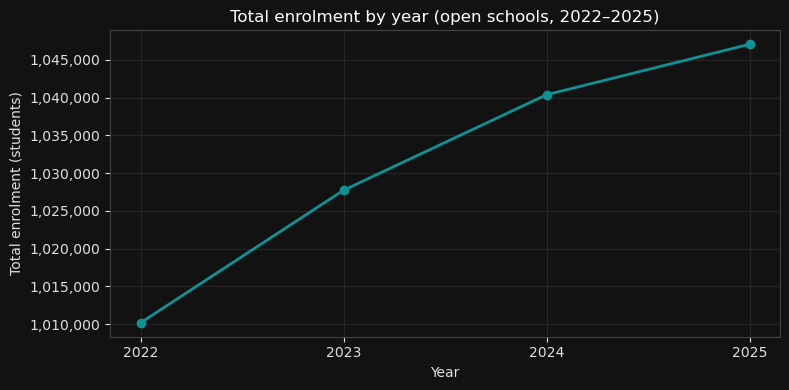

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
years = totals_by_year["Census_Year"]

ax.plot(years, totals_by_year["Grand_Total"], marker="o", color=DARK_COLORS[2], linewidth=2)
ax.set_xticks(years)
ax.set_xlabel("Year")
ax.set_ylabel("Total enrolment (students)")
ax.set_title("Total enrolment by year (open schools, 2022–2025)")
ax.yaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> The total enrolment rises every year roughly 1.74% (2022 to 2023), 1.23% (2023 2024), 0.64% (2024→2025). So there is an upword trend, but the pace of growth eases in the last year.</p>


**Step 19**  
Lets split enrolment into primary and secondary schools, to see whether movement in total enrolment is driven more by primary schools, secondary schools, or both.

*Separating primary and secondary enrolment helps identify whether growth patterns differ across school types rather than assuming the system changes uniformly.*

In [51]:
split_by_year = (
    df.groupby("Census_Year", as_index=False)[["Primary_Total", "Secondary_Total", "Grand_Total"]]
    .sum()
    .sort_values("Census_Year")
)
# year on year change
for col in ["Primary_Total", "Secondary_Total"]:
    split_by_year[f"{col}_pct_yoy"] = split_by_year[col].pct_change() * 100

print(split_by_year)

   Census_Year  Primary_Total  Secondary_Total  Grand_Total  \
0         2022       560229.7         449953.3    1010183.0   
1         2023       566597.6         461145.5    1027743.1   
2         2024       569254.3         471135.3    1040389.6   
3         2025       566084.5         480987.5    1047072.0   

   Primary_Total_pct_yoy  Secondary_Total_pct_yoy  
0                    NaN                      NaN  
1               1.136659                 2.487414  
2               0.468887                 2.166301  
3              -0.556834                 2.091161  


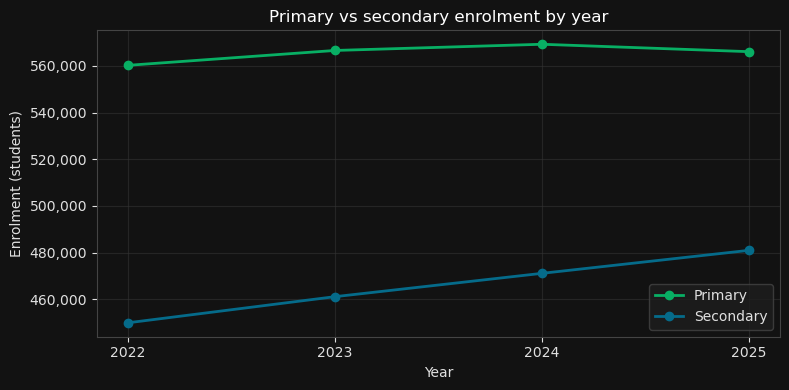

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
years = split_by_year["Census_Year"]

ax.plot(years, split_by_year["Primary_Total"], marker="o", label="Primary", color=DARK_COLORS[0], linewidth=2)
ax.plot(years, split_by_year["Secondary_Total"], marker="o", label="Secondary", color=DARK_COLORS[3], linewidth=2)
ax.set_xticks(years)
ax.set_xlabel("Year")
ax.set_ylabel("Enrolment (students)")
ax.set_title("Primary vs secondary enrolment by year")
ax.yaxis.set_major_formatter(student_formatter)
ax.legend(facecolor="#1e1e1e", edgecolor="#444444", labelcolor="#e0e0e0")
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> Secondary enrolment rises steadily each year, Primary enrolment rises from 2022 to 2024, then falls slightly from 2024 to 2025. The total enrolment still rises into 2025 because secondary growth more than offsets the small primary pullback in that last year.</p>

### Prep and Year 7 - simple entry signals
**Step 20**  
Lets check the trend at entry points. The below code sums Prep enrolment, Year 7 enrolment, and overall total enrolment across all schools. Year-on-year percentage change is calculated for Prep and Year 7 separately. 

*Prep and Year 7 are major entry points into primary and secondary school. Analysing these year levels provides an early signal of changing enrolment demand and future pressure points.*

In [54]:
entry_by_year = (
    df.groupby("Census_Year", as_index=False)[["Prep_Total", "Year_7_Total", "Grand_Total"]]
    .sum()
    .sort_values("Census_Year")
)

entry_by_year["prep_pct_yoy"] = entry_by_year["Prep_Total"].pct_change() * 100
entry_by_year["y7_pct_yoy"] = entry_by_year["Year_7_Total"].pct_change() * 100

print(entry_by_year)

   Census_Year  Prep_Total  Year_7_Total  Grand_Total  prep_pct_yoy  \
0         2022     79100.4       77963.0    1010183.0           NaN   
1         2023     78217.8       78807.7    1027743.1     -1.115797   
2         2024     76563.4       79402.2    1040389.6     -2.115120   
3         2025     75529.7       82384.1    1047072.0     -1.350123   

   y7_pct_yoy  
0         NaN  
1    1.083463  
2    0.754368  
3    3.755438  


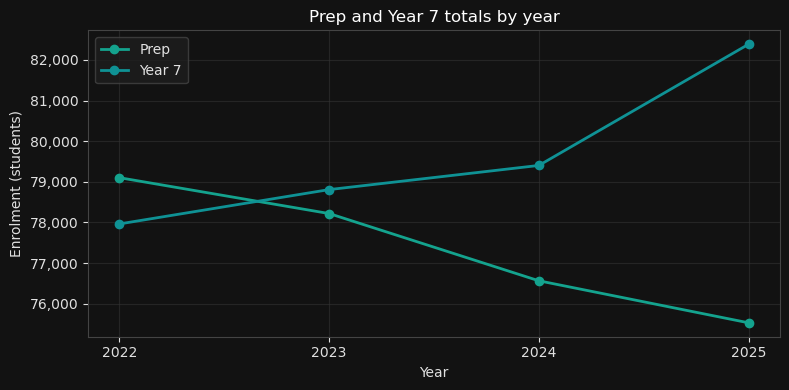

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
years = entry_by_year["Census_Year"]

ax.plot(years, entry_by_year["Prep_Total"], marker="o", label="Prep", color=DARK_COLORS[1], linewidth=2)
ax.plot(years, entry_by_year["Year_7_Total"], marker="o", label="Year 7", color=DARK_COLORS[2], linewidth=2)
ax.set_xticks(years)
ax.set_xlabel("Year")
ax.set_ylabel("Enrolment (students)")
ax.set_title("Prep and Year 7 totals by year")
ax.yaxis.set_major_formatter(student_formatter)
ax.legend(facecolor="#1e1e1e", edgecolor="#444444", labelcolor="#e0e0e0")
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> Prep enrolments fall every year and secondary enrolments rise evey year, this highlights shifting pressure toward typical secondary entry in the aggregate totals, while the overall total can still increase if secondary and other year levels grow enough.</p>

### LGA change from 2022 to 2025
**Step 21**  
Lets segregate the growth by LGAs, The code table computes absolute change between 2022 to 2025 and percentage change relative to 2022. LGAs are sorted by absolute change only, and the percentage change is shown alongside as supporting context.

*Comparing enrolment change by LGA helps identify which areas are growing fastest and which may require additional schools, facilities, or resources in future.*

In [57]:
lga_year = df.groupby(["LGA_Name", "Census_Year"], as_index=False)["Grand_Total"].sum()

wide = lga_year.pivot(index="LGA_Name", columns="Census_Year", values="Grand_Total")

wide["change_22_25"] = wide[2025] - wide[2022]
wide["pct_change_22_25"] = (wide[2025] / wide[2022] - 1) * 100

wide_sorted = wide.sort_values("change_22_25", ascending=False)

print("Top 15 LGAs by absolute change (2022 to 2025), with % change shown:")
print(wide_sorted[["change_22_25", "pct_change_22_25"]].head(15))

Top 15 LGAs by absolute change (2022 to 2025), with % change shown:
Census_Year            change_22_25  pct_change_22_25
LGA_Name                                             
Casey (C)                    5791.5          9.792351
Melton (C)                   4817.3         16.192605
Greater Dandenong (C)        4197.2         16.708399
Wyndham (C)                  3707.6          6.654008
Greater Geelong (C)          3084.7          6.907122
Hume (C)                     3077.1          6.745689
Melbourne (C)                1978.7         15.122589
Darebin (C)                  1455.1          7.606139
Wodonga (C)                  1199.4         13.492626
Mitchell (S)                 1148.0         14.214254
Monash (C)                   1064.9          3.241784
Glen Eira (C)                 978.5          4.716936
Ballarat (C)                  969.6          4.401910
Whittlesea (C)                825.0          2.434583
Moorabool (S)                 661.6          9.073703


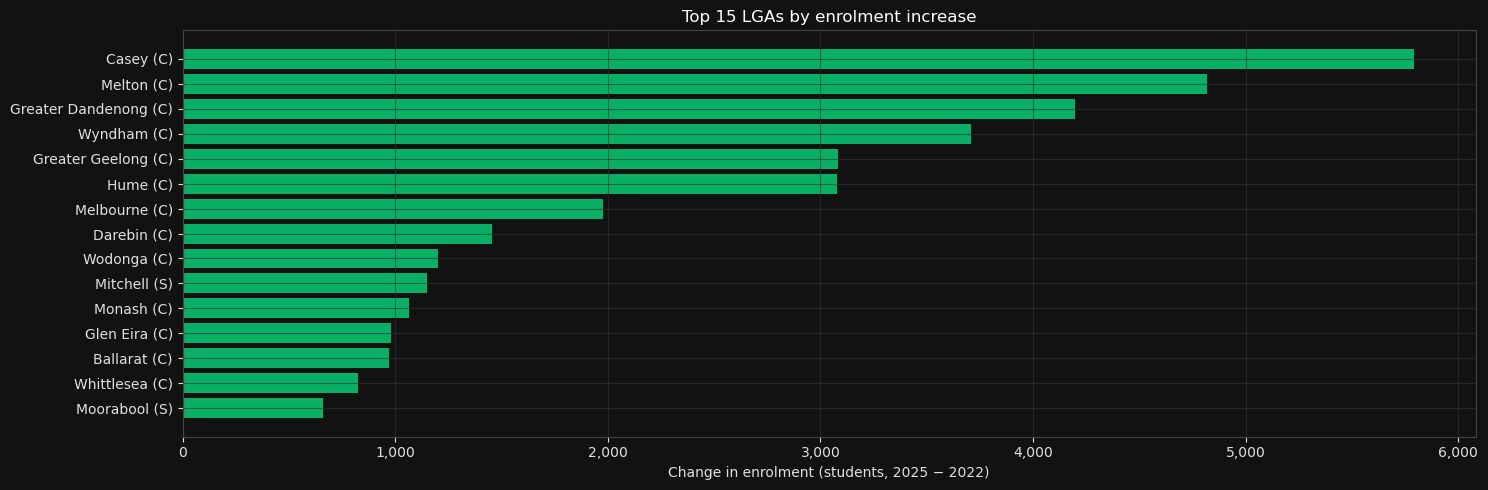

In [58]:
top10 = wide.sort_values("change_22_25", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(15, 5))
ax.barh(top10.index, top10["change_22_25"], color=DARK_COLORS[0])
ax.invert_yaxis()
ax.set_xlabel("Change in enrolment (students, 2025 − 2022)")
ax.set_title("Top 15 LGAs by enrolment increase")
ax.xaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> Casey, Melton and Greater Dandenong have sizeable increase in student numbers.</p>

**Step 22**  
Lets see the LGAs with largest fall.

*Looking at LGAs with declining enrolment helps identify areas where demand may be stabilising or decreasing, which is also important for planning decisions.*

In [60]:
print("15 LGAs with the largest absolute decline (2022 to 2025), with % change shown:")
print(wide_sorted[["change_22_25", "pct_change_22_25"]].tail(15).sort_values("change_22_25"))

15 LGAs with the largest absolute decline (2022 to 2025), with % change shown:
Census_Year               change_22_25  pct_change_22_25
LGA_Name                                                
Brimbank (C)                    -462.1         -1.541556
Boroondara (C)                  -421.7         -1.218962
Mornington Peninsula (S)        -367.1         -1.450701
Greater Shepparton (C)          -310.6         -2.720624
South Gippsland (S)             -215.8         -4.403003
Bayside (C)                     -198.1         -1.274586
Wangaratta (RC)                 -168.4         -3.303580
Kingston (C)                    -158.2         -0.674170
Campaspe (S)                    -156.6         -2.378385
Hepburn (S)                     -154.3        -10.184818
Corangamite (S)                 -143.4         -5.766679
Buloke (S)                       -85.8        -10.037436
Moyne (S)                        -80.8         -5.821326
Murrindindi (S)                  -75.2         -4.839125
Mount Ale

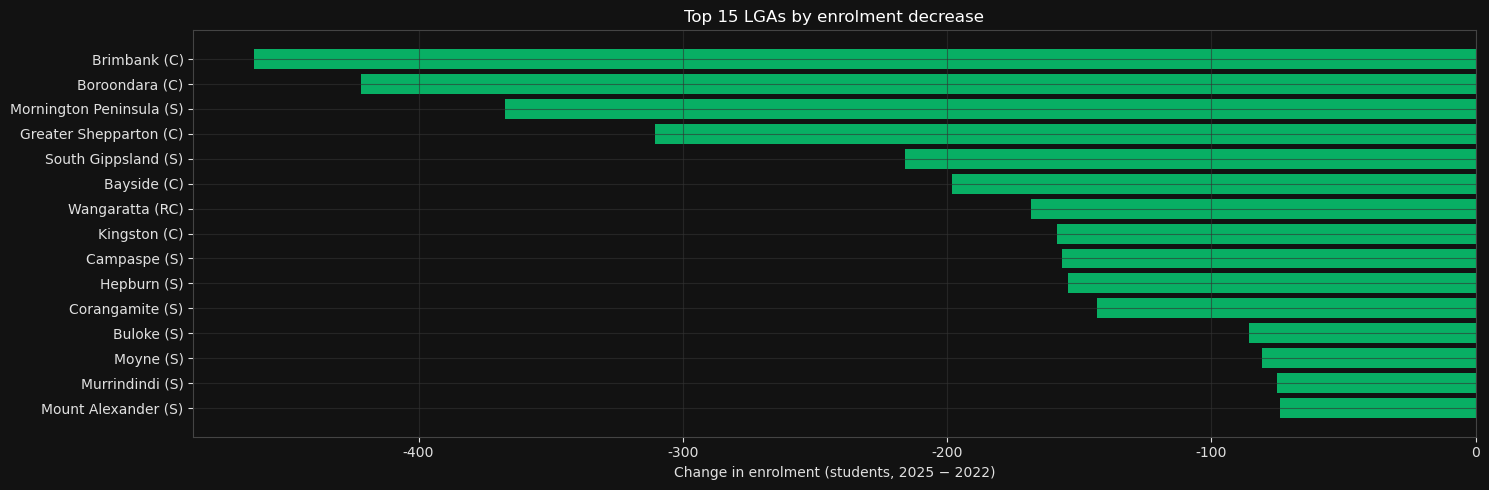

In [61]:
top10 = wide.sort_values("change_22_25", ascending=True).head(15)

fig, ax = plt.subplots(figsize=(15, 5))
ax.barh(top10.index, top10["change_22_25"], color=DARK_COLORS[0])
ax.invert_yaxis()
ax.set_xlabel("Change in enrolment (students, 2025 − 2022)")
ax.set_title("Top 15 LGAs by enrolment decrease")
ax.xaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> The decrease in enrolments is relatively moderate in several large LGAs like Brimbank, Boroondara and Mornington Peninsula.</p>

### School counts per LGA 
**Step 23**  
Lets put school counts next to the top growth LGAs.

*Adding school counts provides context for enrolment growth by showing whether changes are spread across many schools or concentrated in a smaller number of large schools.*

In [63]:
schools_per_lga = df.groupby("LGA_Name")["Unique_School_ID"].nunique()

wide["schools_in_cohort"] = schools_per_lga

wide_sorted = wide.sort_values("change_22_25", ascending=False)
print("Top 15 LGAs by absolute change (2022 to 2025), with % change and school count:")
print(wide_sorted[["change_22_25", "pct_change_22_25", "schools_in_cohort"]].head(15))

Top 15 LGAs by absolute change (2022 to 2025), with % change and school count:
Census_Year            change_22_25  pct_change_22_25  schools_in_cohort
LGA_Name                                                                
Casey (C)                    5791.5          9.792351                 88
Melton (C)                   4817.3         16.192605                 43
Greater Dandenong (C)        4197.2         16.708399                 43
Wyndham (C)                  3707.6          6.654008                 57
Greater Geelong (C)          3084.7          6.907122                 84
Hume (C)                     3077.1          6.745689                 67
Melbourne (C)                1978.7         15.122589                 25
Darebin (C)                  1455.1          7.606139                 43
Wodonga (C)                  1199.4         13.492626                 16
Mitchell (S)                 1148.0         14.214254                 17
Monash (C)                   1064.9          

**Step 24**  
Apply the same for LGAs with decrease in enrolment

*Including school counts for declining LGAs helps interpret whether decreases are widespread across an area or driven by only a few schools.*

In [65]:
print("15 LGAs with the largest absolute decline (2022 to 2025), with % change and school count:")
print(
    wide.sort_values("change_22_25", ascending=True)
    [["change_22_25", "pct_change_22_25", "schools_in_cohort"]]
    .head(15)
)

15 LGAs with the largest absolute decline (2022 to 2025), with % change and school count:
Census_Year               change_22_25  pct_change_22_25  schools_in_cohort
LGA_Name                                                                   
Brimbank (C)                    -462.1         -1.541556                 59
Boroondara (C)                  -421.7         -1.218962                 57
Mornington Peninsula (S)        -367.1         -1.450701                 49
Greater Shepparton (C)          -310.6         -2.720624                 38
South Gippsland (S)             -215.8         -4.403003                 22
Bayside (C)                     -198.1         -1.274586                 27
Wangaratta (RC)                 -168.4         -3.303580                 23
Kingston (C)                    -158.2         -0.674170                 45
Campaspe (S)                    -156.6         -2.378385                 23
Hepburn (S)                     -154.3        -10.184818                 1

### Primary versus secondary within the biggest movers
**Step 25**  
The five local government areas with the largest total enrolment increase between 2022 and 2025 are selected from the earlier ranking. For those LGAs only, primary and secondary enrolment totals are summed by year, then the same start-to-end difference is calculated separately for primary and secondary. 

*Comparing primary and secondary trends within the fastest-growing LGAs helps identify which part of the education system is driving growth in each area.*

In [67]:
top5_lgas = wide_sorted.head(5).index.tolist()

lga_ps = (
    df[df["LGA_Name"].isin(top5_lgas)]
    .groupby(["LGA_Name", "Census_Year"])[["Primary_Total", "Secondary_Total"]]
    .sum()
    .reset_index()
)

wide_p = lga_ps.pivot(index="LGA_Name", columns="Census_Year", values="Primary_Total")
wide_s = lga_ps.pivot(index="LGA_Name", columns="Census_Year", values="Secondary_Total")

split_change = pd.DataFrame(
    {
        "primary_change_22_25": wide_p[2025] - wide_p[2022],
        "secondary_change_22_25": wide_s[2025] - wide_s[2022],
    }
)

print("Top 5 LGAs (by total enrolment growth): primary vs secondary change (2022 to 2025)")
print(split_change.sort_values("primary_change_22_25", ascending=False))

Top 5 LGAs (by total enrolment growth): primary vs secondary change (2022 to 2025)
                       primary_change_22_25  secondary_change_22_25
LGA_Name                                                           
Melton (C)                           2574.5                  2242.8
Casey (C)                            1673.4                  4118.1
Greater Dandenong (C)                1556.8                  2640.4
Greater Geelong (C)                  1507.6                  1577.1
Wyndham (C)                           398.1                  3309.5


<p class="usecase-subsection-blurb"> For Casey, Greater Dandenong and Wyndham, the enrolment growth is mostly secondary. Melton and Greater Geelong have balanced growth.</p>

**Step 26**  
Lets check the five LGAs with largest decline.

*Analysing primary and secondary enrolment separately in declining LGAs helps reveal whether declines affect all school types equally or are concentrated in one sector.*

In [69]:
bottom5_lgas = wide.sort_values("change_22_25", ascending=True).head(5).index.tolist()

lga_ps_b = (
    df[df["LGA_Name"].isin(bottom5_lgas)]
    .groupby(["LGA_Name", "Census_Year"])[["Primary_Total", "Secondary_Total"]]
    .sum()
    .reset_index()
)

wide_pb = lga_ps_b.pivot(index="LGA_Name", columns="Census_Year", values="Primary_Total")
wide_sb = lga_ps_b.pivot(index="LGA_Name", columns="Census_Year", values="Secondary_Total")

split_change_b = pd.DataFrame(
    {
        "primary_change_22_25": wide_pb[2025] - wide_pb[2022],
        "secondary_change_22_25": wide_sb[2025] - wide_sb[2022],
    }
)

print("Bottom 5 LGAs (by total enrolment decline): primary vs secondary change (2022 to 2025)")
print(split_change_b.sort_values("primary_change_22_25", ascending=True))

Bottom 5 LGAs (by total enrolment decline): primary vs secondary change (2022 to 2025)
                          primary_change_22_25  secondary_change_22_25
LGA_Name                                                              
Brimbank (C)                            -882.0                   419.9
Boroondara (C)                          -511.3                    89.6
Mornington Peninsula (S)                -486.4                   119.3
Greater Shepparton (C)                  -205.2                  -105.4
South Gippsland (S)                     -157.2                   -58.6


<p class="usecase-subsection-blurb"> Brimbank, Boroondara, and Mornington Peninsula show the same pattern: primary enrolment falls a lot, while secondary rises. Greater Shepparton and South Gippsland show declines in both primary and secondary.</p>

### School-level concentration - case studies
**Step 27**  
Lets focus on one LGA at a time, in the below segment the ennrolment is compared between 2022 and 2025 at the individual school level using the unique school identifier. Schools are ranked by absolute change, and each school’s change is expressed as a percentage of the LGA’s net change over the same period. 

*School-level analysis helps determine whether enrolment growth or decline is spread across an entire LGA or concentrated within a few schools, providing a more detailed view of local education pressure.*


In [71]:
# checking for Casey LGA
LGA_FOCUS = "Casey (C)"  # change to any LGA name, e.g. "Melton (C)"

sub = df[df["LGA_Name"] == LGA_FOCUS].copy()

# Pivot on unique school ID only (names can vary by year and would split rows)
wide_school = sub.pivot_table(
    index="Unique_School_ID",
    columns="Census_Year",
    values="Grand_Total",
    aggfunc="sum",
)

wide_school["change_22_25"] = wide_school[2025] - wide_school[2022]

# One display name per school (latest census year wins)
names = (
    sub.sort_values("Census_Year", ascending=False)
    .drop_duplicates("Unique_School_ID")[["Unique_School_ID", "School_Name_enrol"]]
    .set_index("Unique_School_ID")["School_Name_enrol"]
)
wide_school = wide_school.join(names.rename("School_Name_enrol"))

lga_total_change = wide_school["change_22_25"].sum()

if lga_total_change != 0:
    wide_school["pct_of_lga_change"] = wide_school["change_22_25"] / lga_total_change * 100
else:
    wide_school["pct_of_lga_change"] = float("nan")

print(f"{LGA_FOCUS} — total enrolment change 2022→2025 (this cohort): {lga_total_change:,.1f}")

print("\nTop 15 schools by absolute increase:")
print(
    wide_school.sort_values("change_22_25", ascending=False)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)

print("\n15 schools with largest decreases:")
print(
    wide_school.sort_values("change_22_25", ascending=True)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)


Casey (C) — total enrolment change 2022→2025 (this cohort): 5,791.5

Top 15 schools by absolute increase:
                    2022    2025                  School_Name_enrol  \
Unique_School_ID                                                      
107748             461.0  1596.6  Cranbourne West Secondary College   
107086             138.0  1069.0            Clyde Secondary College   
108421            1777.0  2368.8                    Kambrya College   
105581             802.0  1370.0        Ramlegh Park Primary School   
105588             221.0   744.6         Clyde Creek Primary School   
201848            1906.0  2248.0        Hillcrest Christian College   
105570             690.8  1029.4        Casey Fields Primary School   
105385             376.0   686.0            Grayling Primary School   
201920            1801.0  2109.0                 St Peter's College   
108874            1732.6  2005.8           Alkira Secondary College   
201679             782.0  1047.7         M

In [72]:
# strip odd characters
import re
def safe_label(s):
    s = str(s)
    s = s.replace("â€™", "'").replace("â", "'")  # common mojibake
    s = re.sub(r"[^\x20-\x7E]", "", s)          # keep normal printable ASCII
    return s.strip()[:40]

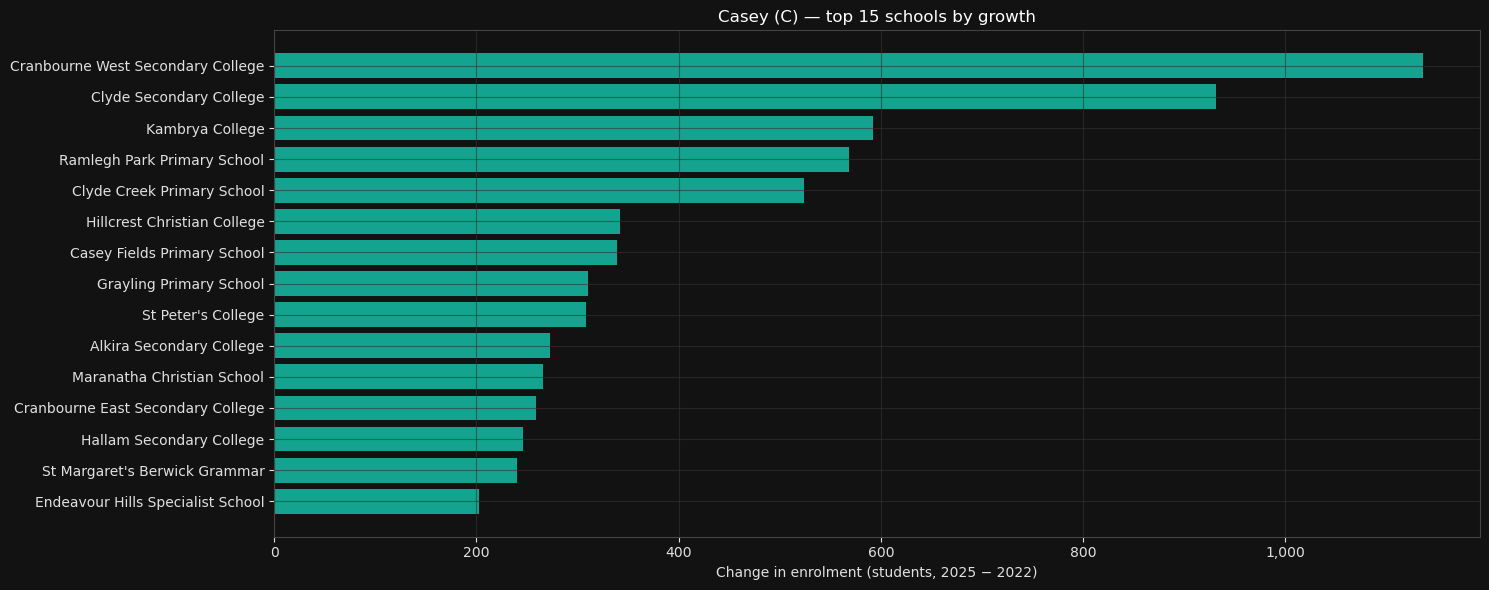

In [73]:
top_schools = wide_school.sort_values("change_22_25", ascending=False).head(15)
labels = top_schools["School_Name_enrol"].apply(safe_label)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(labels, top_schools["change_22_25"], color=DARK_COLORS[1])
ax.invert_yaxis()
ax.set_xlabel("Change in enrolment (students, 2025 − 2022)")
ax.set_title(f"{LGA_FOCUS} — top 15 schools by growth")
ax.xaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> For Casey, the net growth is concentrated in a few schools. The top three, Cranbourne West SC, Clyde SC and Kambrya College account for about 19.6%, 16.1% and 10.2% of Casey's net change. So roughly 46% of the LGA's total growth comes from just those three.</p>

**Step 28**  
Lets check Melton.

In [75]:
# checking for Melton LGA
LGA_FOCUS = "Melton (C)"  

sub = df[df["LGA_Name"] == LGA_FOCUS].copy()

# Pivot on unique school ID only (names can vary by year and would split rows)
wide_school = sub.pivot_table(
    index="Unique_School_ID",
    columns="Census_Year",
    values="Grand_Total",
    aggfunc="sum",
)

wide_school["change_22_25"] = wide_school[2025] - wide_school[2022]

# One display name per school (latest census year wins)
names = (
    sub.sort_values("Census_Year", ascending=False)
    .drop_duplicates("Unique_School_ID")[["Unique_School_ID", "School_Name_enrol"]]
    .set_index("Unique_School_ID")["School_Name_enrol"]
)
wide_school = wide_school.join(names.rename("School_Name_enrol"))

lga_total_change = wide_school["change_22_25"].sum()

if lga_total_change != 0:
    wide_school["pct_of_lga_change"] = wide_school["change_22_25"] / lga_total_change * 100
else:
    wide_school["pct_of_lga_change"] = float("nan")

print(f"{LGA_FOCUS} — total enrolment change 2022→2025 (this cohort): {lga_total_change:,.1f}")

print("\nTop 15 schools by absolute increase:")
print(
    wide_school.sort_values("change_22_25", ascending=False)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)

print("\n15 schools with largest decreases:")
print(
    wide_school.sort_values("change_22_25", ascending=True)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)


Melton (C) — total enrolment change 2022→2025 (this cohort): 4,817.3

Top 15 schools by absolute increase:
                    2022    2025  \
Unique_School_ID                   
201811            1212.0  1864.0   
105583             711.5  1347.0   
105575             791.0  1298.0   
108784            1194.0  1678.0   
105578              63.0   520.6   
107247            1261.4  1698.2   
201894             919.0  1248.0   
202103             835.0  1148.0   
202242             182.0   467.0   
100919             297.0   569.0   
202241              36.0   199.0   
105502             284.2   445.6   
102479             395.0   556.2   
108911             816.2   962.4   
105311             307.0   450.0   

                                                School_Name_enrol  \
Unique_School_ID                                                    
201811                                St Francis Catholic College   
105583                                Strathtulloh Primary School   
1055

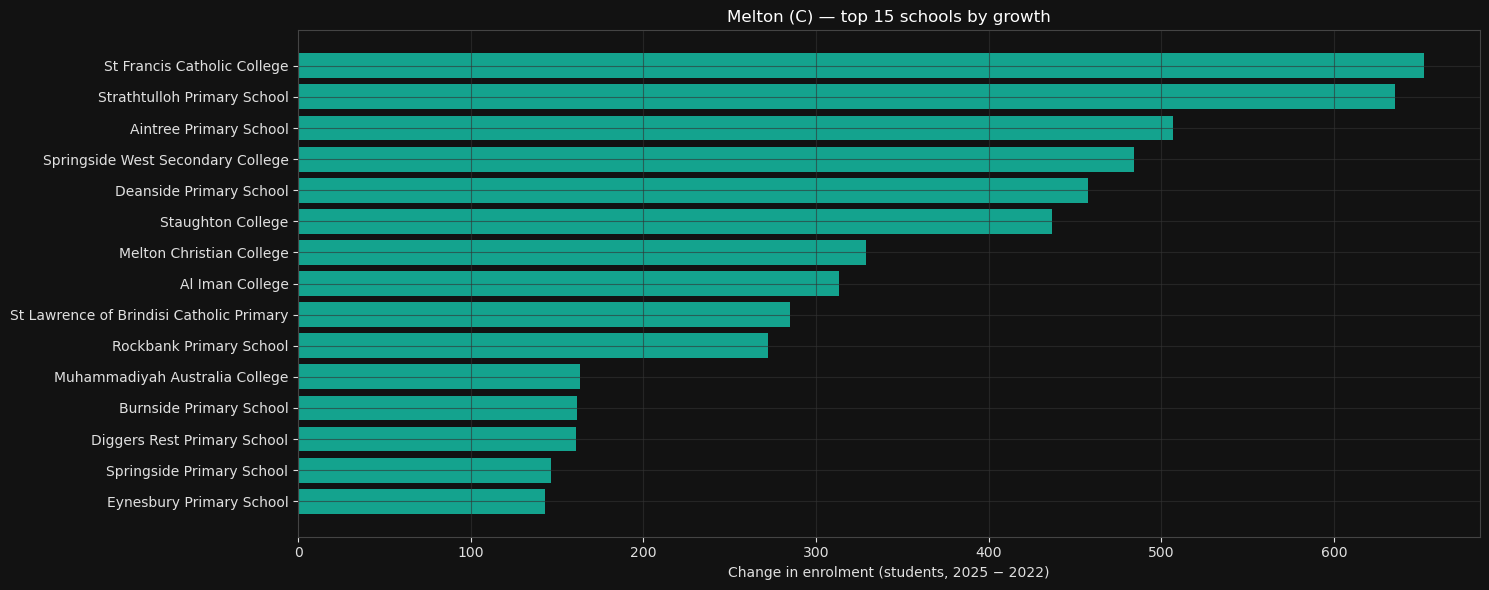

In [76]:
top_schools = wide_school.sort_values("change_22_25", ascending=False).head(15)
labels = top_schools["School_Name_enrol"].apply(safe_label)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(labels, top_schools["change_22_25"], color=DARK_COLORS[1])
ax.invert_yaxis()
ax.set_xlabel("Change in enrolment (students, 2025 − 2022)")
ax.set_title(f"{LGA_FOCUS} — top 15 schools by growth")
ax.xaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> Melton's enrolment growth is quite concentrated, but slightly less “top-heavy” than Casey. Top five schools sum to roughly 57% of Melton’s net growth. The largest increases mix Catholic/independent colleges with newer/growing government primaries and a secondary college (e.g. Springside West SC, Staughton College). Several names look like greenfield growth corridors (Strathtulloh, Aintree, Deanside, Springside schools).</p>

**Step 29**  
Lets check Greater Dandenong

In [78]:
# checking for Greater Dandenon LGA
LGA_FOCUS = "Greater Dandenong (C)"  

sub = df[df["LGA_Name"] == LGA_FOCUS].copy()

# Pivot on unique school ID only (names can vary by year and would split rows)
wide_school = sub.pivot_table(
    index="Unique_School_ID",
    columns="Census_Year",
    values="Grand_Total",
    aggfunc="sum",
)

wide_school["change_22_25"] = wide_school[2025] - wide_school[2022]

# One display name per school (latest census year wins)
names = (
    sub.sort_values("Census_Year", ascending=False)
    .drop_duplicates("Unique_School_ID")[["Unique_School_ID", "School_Name_enrol"]]
    .set_index("Unique_School_ID")["School_Name_enrol"]
)
wide_school = wide_school.join(names.rename("School_Name_enrol"))

lga_total_change = wide_school["change_22_25"].sum()

if lga_total_change != 0:
    wide_school["pct_of_lga_change"] = wide_school["change_22_25"] / lga_total_change * 100
else:
    wide_school["pct_of_lga_change"] = float("nan")

print(f"{LGA_FOCUS} — total enrolment change 2022→2025 (this cohort): {lga_total_change:,.1f}")

print("\nTop 15 schools by absolute increase:")
print(
    wide_school.sort_values("change_22_25", ascending=False)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)

print("\n15 schools with largest decreases:")
print(
    wide_school.sort_values("change_22_25", ascending=True)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)


Greater Dandenong (C) — total enrolment change 2022→2025 (this cohort): 4,197.2

Top 15 schools by absolute increase:
                    2022    2025                   School_Name_enrol  \
Unique_School_ID                                                       
201191            2467.0  4895.0                  Haileybury College   
201936            2373.0  2911.0                     Minaret College   
108867            1840.4  2195.3       Keysborough Secondary College   
201899             742.0   980.8                    Nazareth College   
105435             507.6   679.6               Carwatha College P-12   
201990             736.0   873.0                     Mt Hira College   
105572             348.4   485.0  Keysborough Gardens Primary School   
108813             432.0   556.6        Noble Park Secondary College   
101403             357.0   478.0            Dandenong Primary School   
108749             765.0   882.0  Noble Park English Language School   
104807            

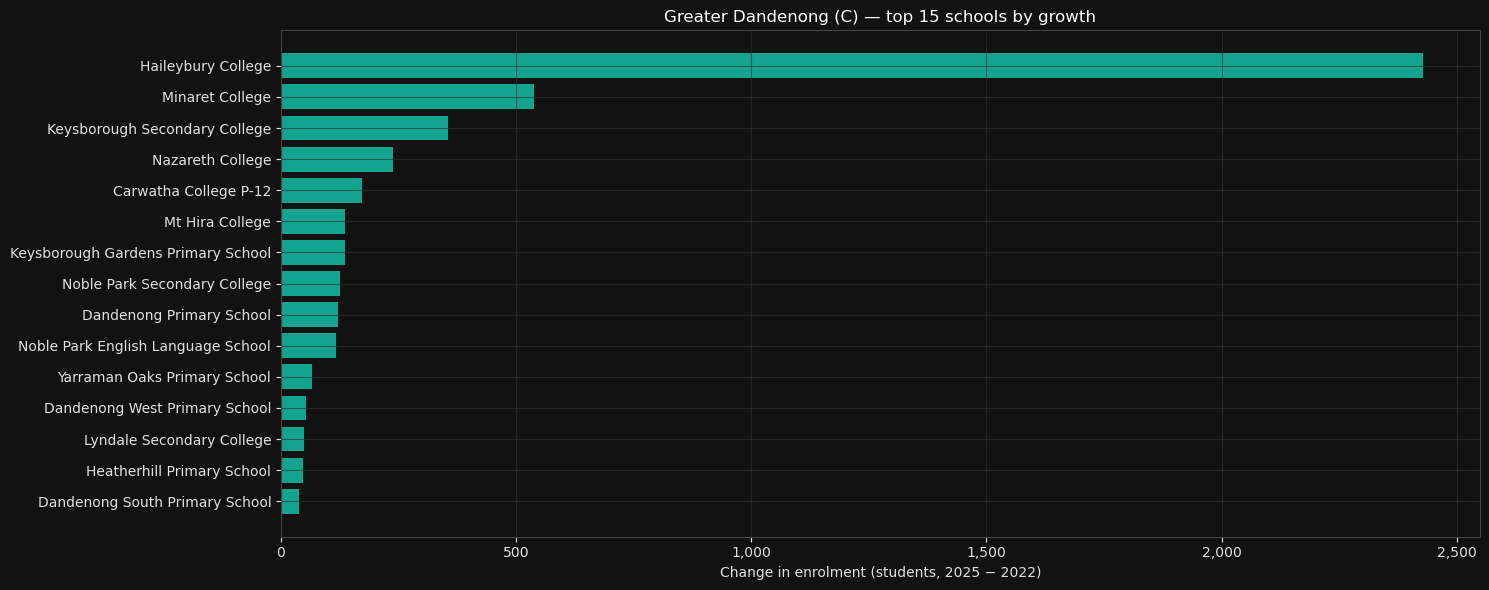

In [79]:
top_schools = wide_school.sort_values("change_22_25", ascending=False).head(15)
labels = top_schools["School_Name_enrol"].apply(safe_label)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(labels, top_schools["change_22_25"], color=DARK_COLORS[1])
ax.invert_yaxis()
ax.set_xlabel("Change in enrolment (students, 2025 − 2022)")
ax.set_title(f"{LGA_FOCUS} — top 15 schools by growth")
ax.xaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> Extreme concentration — one campus dominates, The stand-out school is Haileybury College, where the enrolment increased by 57.8%, from 2,467 (2022) to 4,895 (2025), about +2,428 students. After Haileybury, the next largest absolute gains include Minaret College, Keysborough Secondary College, and several non-government colleges plus government primary and secondary schools (e.g. Noble Park Secondary, Carwatha P–12, Keysborough Gardens Primary).</p>

**Step 30**  
Lets check Wyndham

In [81]:
# checking for Wyndham LGA
LGA_FOCUS = "Wyndham (C)"  

sub = df[df["LGA_Name"] == LGA_FOCUS].copy()

# Pivot on unique school ID only (names can vary by year and would split rows)
wide_school = sub.pivot_table(
    index="Unique_School_ID",
    columns="Census_Year",
    values="Grand_Total",
    aggfunc="sum",
)

wide_school["change_22_25"] = wide_school[2025] - wide_school[2022]

# One display name per school (latest census year wins)
names = (
    sub.sort_values("Census_Year", ascending=False)
    .drop_duplicates("Unique_School_ID")[["Unique_School_ID", "School_Name_enrol"]]
    .set_index("Unique_School_ID")["School_Name_enrol"]
)
wide_school = wide_school.join(names.rename("School_Name_enrol"))

lga_total_change = wide_school["change_22_25"].sum()

if lga_total_change != 0:
    wide_school["pct_of_lga_change"] = wide_school["change_22_25"] / lga_total_change * 100
else:
    wide_school["pct_of_lga_change"] = float("nan")

print(f"{LGA_FOCUS} — total enrolment change 2022→2025 (this cohort): {lga_total_change:,.1f}")

print("\nTop 15 schools by absolute increase:")
print(
    wide_school.sort_values("change_22_25", ascending=False)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)

print("\n15 schools with largest decreases:")
print(
    wide_school.sort_values("change_22_25", ascending=True)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)


Wyndham (C) — total enrolment change 2022→2025 (this cohort): 3,707.6

Top 15 schools by absolute increase:
                    2022    2025                      School_Name_enrol  \
Unique_School_ID                                                          
108303            1446.6  2163.6                  Saltwater P-9 College   
201775            1486.0  2136.0              Westbourne Grammar School   
108397            1069.0  1702.0             Dohertys Creek P-9 College   
201957            1265.0  1844.0             Good News Lutheran College   
202073            1548.0  2008.0           Islamic College of Melbourne   
105580             301.0   724.0               Riverbend Primary School   
105361             475.0   897.0               Riverwalk Primary School   
201846            1997.0  2359.0            Heathdale Christian College   
201906            2235.6  2570.0                       Al-Taqwa College   
202235             211.0   406.0  St Josephâs Catholic Primary Sc

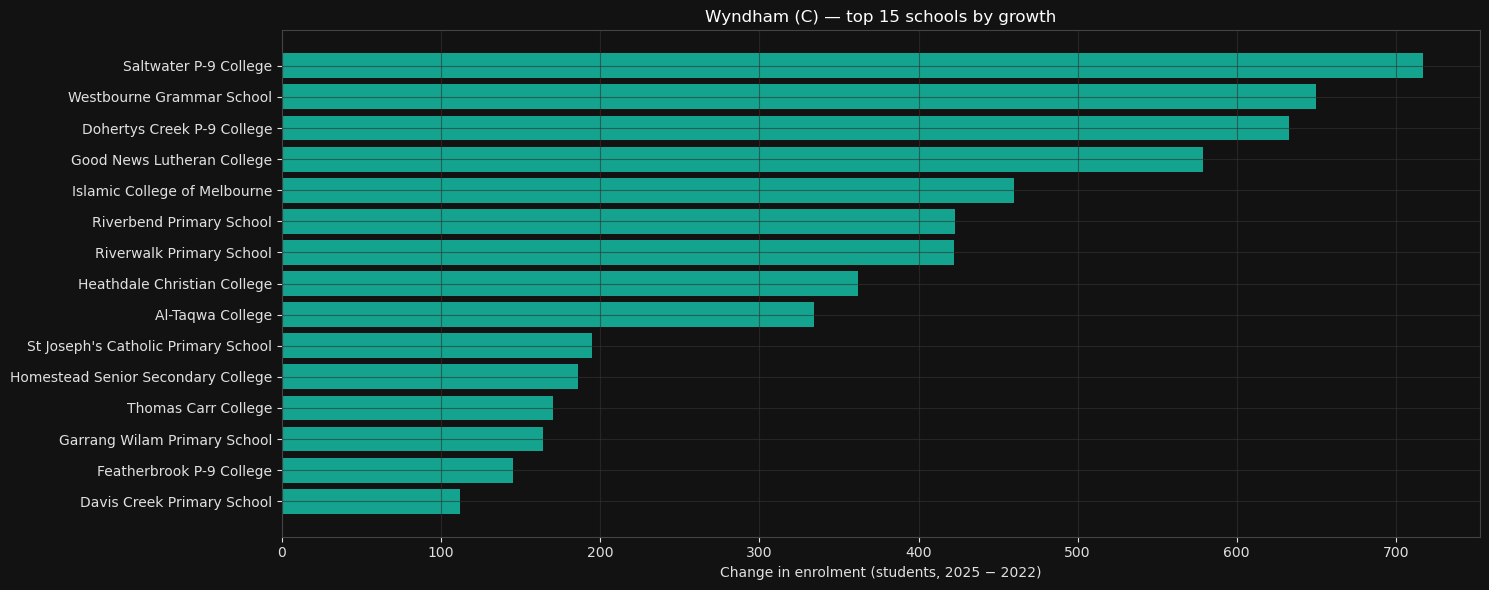

In [82]:
top_schools = wide_school.sort_values("change_22_25", ascending=False).head(15)
labels = top_schools["School_Name_enrol"].apply(safe_label)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(labels, top_schools["change_22_25"], color=DARK_COLORS[1])
ax.invert_yaxis()
ax.set_xlabel("Change in enrolment (students, 2025 − 2022)")
ax.set_title(f"{LGA_FOCUS} — top 15 schools by growth")
ax.xaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> Wyndham’s net enrolment increase is 3,708 students (2022 to 2025). Wyndham’s headline growth is not subtle or evenly distributed, a handful of campuses—including newer P–9 colleges, large non-government schools, and growth-area primaries—carry most of the net increase. The top five risers sum to roughly 19.3 + 17.5 + 17.1 + 15.6 + 12.4 = 82% of Wyndham’s net change.</p>

**Step 31**  
Lets check Greater Geelong

In [84]:
# checking for Greater Geelong LGA
LGA_FOCUS = "Greater Geelong (C)"  

sub = df[df["LGA_Name"] == LGA_FOCUS].copy()

# Pivot on unique school ID only (names can vary by year and would split rows)
wide_school = sub.pivot_table(
    index="Unique_School_ID",
    columns="Census_Year",
    values="Grand_Total",
    aggfunc="sum",
)

wide_school["change_22_25"] = wide_school[2025] - wide_school[2022]

# One display name per school (latest census year wins)
names = (
    sub.sort_values("Census_Year", ascending=False)
    .drop_duplicates("Unique_School_ID")[["Unique_School_ID", "School_Name_enrol"]]
    .set_index("Unique_School_ID")["School_Name_enrol"]
)
wide_school = wide_school.join(names.rename("School_Name_enrol"))

lga_total_change = wide_school["change_22_25"].sum()

if lga_total_change != 0:
    wide_school["pct_of_lga_change"] = wide_school["change_22_25"] / lga_total_change * 100
else:
    wide_school["pct_of_lga_change"] = float("nan")

print(f"{LGA_FOCUS} — total enrolment change 2022→2025 (this cohort): {lga_total_change:,.1f}")

print("\nTop 15 schools by absolute increase:")
print(
    wide_school.sort_values("change_22_25", ascending=False)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)

print("\n15 schools with largest decreases:")
print(
    wide_school.sort_values("change_22_25", ascending=True)
    .head(15)[[2022, 2025, "School_Name_enrol", "change_22_25", "pct_of_lga_change"]]
)


Greater Geelong (C) — total enrolment change 2022→2025 (this cohort): 3,084.7

Top 15 schools by absolute increase:
                    2022    2025  \
Unique_School_ID                   
202231             559.0  1356.2   
108820             563.6  1075.3   
202056             826.0  1337.0   
105571             297.0   622.0   
105564             632.0   890.0   
202229             303.0   507.0   
108210             918.6  1095.2   
100769             719.0   870.0   
201953            1832.0  1926.0   
200510            1460.0  1552.4   
200450            1337.0  1413.0   
100283             258.0   332.0   
200548            1384.0  1457.0   
104962             224.0   296.0   
104983              51.0    99.0   

                                              School_Name_enrol  change_22_25  \
Unique_School_ID                                                                
202231                                     Iona College Geelong         797.2   
108820                      

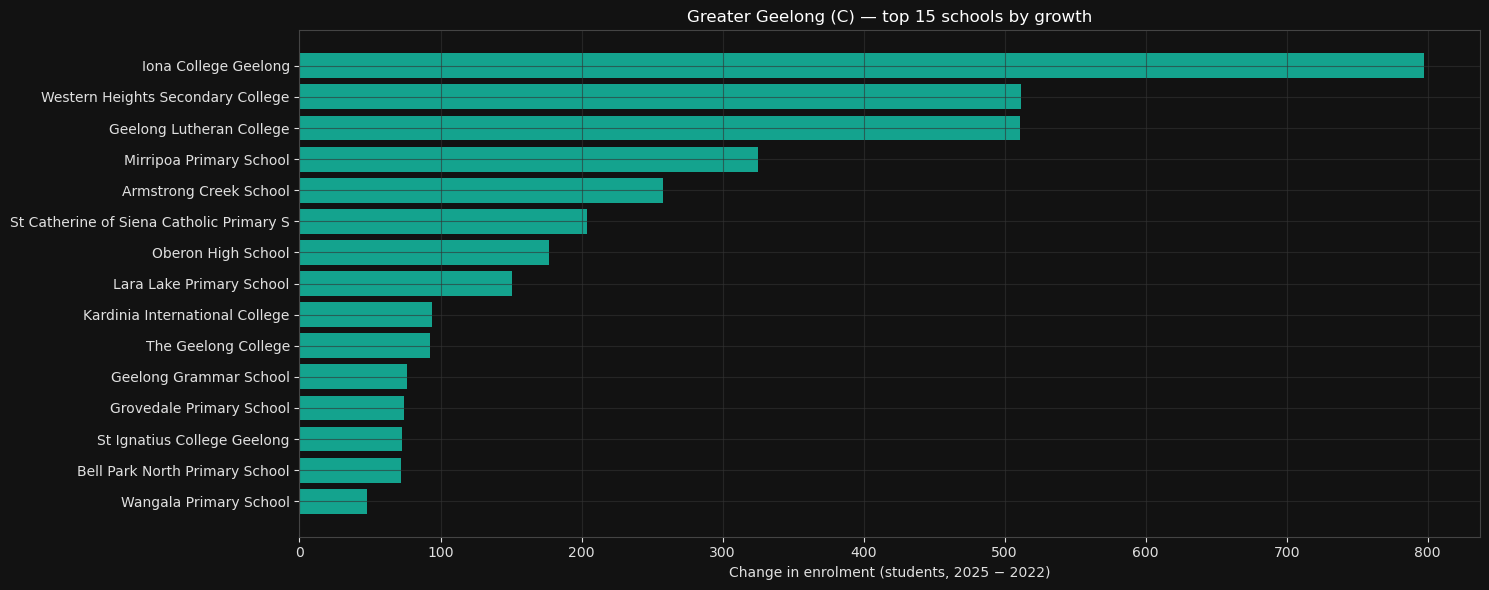

In [85]:
top_schools = wide_school.sort_values("change_22_25", ascending=False).head(15)
labels = top_schools["School_Name_enrol"].apply(safe_label)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(labels, top_schools["change_22_25"], color=DARK_COLORS[1])
ax.invert_yaxis()
ax.set_xlabel("Change in enrolment (students, 2025 − 2022)")
ax.set_title(f"{LGA_FOCUS} — top 15 schools by growth")
ax.xaxis.set_major_formatter(student_formatter)
apply_dark_theme(ax, fig)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-blurb"> Greater Geelong's growth is meaningfully concentrated, but not as extreme as Greater Dandenong. Iona College Geelong alone accounts for about 26% of the LGA’s net increase. Western Heights Secondary College and Geelong Lutheran College have similar growth of almost 17% each, together the top three explain roughly about 60% of net growth.</p>

## Conclusions — five fast-growing LGAs (2022 to 2025, this cohort)

**Scope**  
These paragraphs summarise Casey, Melton, Greater Dandenong, Wyndham, and Greater Geelong using the same cohort as the notebook: open schools present in all four census years, matched to locations, then compared by LGA. That keeps year-to-year comparisons fair, but it is not a complete count of every school in Victoria (new schools, closures, and schools missing a year sit outside this definition).

**Shared pattern**  
Across the five areas, total enrolment for the cohort rises by large amounts in absolute terms. They are useful examples of where enrolment pressure shows up on the map for this assignment, even though the cohort definition should stay visible whenever numbers are quoted.

**Casey** grew the most in this set (about 5,800 students net). Growth is concentrated in a relatively small number of schools, with very large increases at some secondary campuses, while other schools decline. The story is net growth with local winners and losers, not an even rise everywhere.

**Melton** also grew strongly (about 4,800 students) with fewer schools in the cohort than Casey, so change is felt more per school on average. Fast growers mix newer primary schools, secondary colleges, and non-government schools, which fits outer suburban greenfield expansion.

**Greater Dandenong** grew by about 4,200 students, but school-level detail shows one campus, Haileybury College, accounts for most of the LGA net change. LGA totals can therefore be driven by a single large school’s expansion, and sector context matters when interpreting the headline number.

**Wyndham** grew by about 3,700 students with a very top-heavy pattern: a small group of campuses accounts for most of the net increase across P–9 and primary schools in growth suburbs and large non-government schools. Several large P–9 campuses decline at the same time, which fits churn as estates mature and new schools open nearby.

**Greater Geelong** grew by about 3,100 students with concentration among a few large campuses (including Iona College Geelong, Western Heights Secondary College, and Geelong Lutheran College) plus growth-area primary schools such as those linked to Armstrong Creek. Net growth sits alongside moderate declines at other schools.

**Takeaway**  
For education planning style thinking with administrative data, the useful insight is not only how much an LGA grew, but which schools carry the change. When independent or large non-government campuses drive much of the net movement, LGA headlines read differently from a story about even growth across all local schools. 